# Inverted 📉
### When the yield curve inverts, should you sell?

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Forecasts equity downturns?: Confirmed](https://img.shields.io/badge/Forecasts_equity_downturns%3F-Confirmed-8b949e?style=flat-square)

Every modern recession was preceded by an inverted yield curve — short rates above long ones. And the signal is real for stocks too: after an inversion, the next 18 months of equities averaged +1% vs +16% normally. But it's a slow warning, not a sell button — markets often climb for a year after the curve inverts.

> 📓 **Plain-language layer.** The horizon split and the variable-lead caveat are in **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))  # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))        # study package (inverted/)
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5); plt.rcParams["axes.grid"] = True
import numpy as np, pandas as pd
from inverted import data, strategy as st
d = data.fetch_panel()                         # cache-first
slope = st.curve_slope(d["long_yield"], d["short_yield"])


## The answer first 🎯

| The question | The data (1985–2026) |
|---|---|
| "Does inversion forecast weak stocks?" | Yes: next 18m **+1% vs +16%** normal. |
| "At 2 years?" | Even starker: **−9% vs +22%**. |
| "So sell on inversion?" | Near-term it's mild (12m gap −4%); markets often rise first. |

## 1 · The claim

The 10-year-minus-3-month Treasury slope inverts (<0) before recessions (Estrella & Mishkin). The market lore: when it inverts, brace for a downturn — and weak equity returns.

## 2 · So what?

The inversion is the single most-watched recession signal, and it inverted in 2022–23. If it genuinely forecasts weak stock returns, it's a real risk-management input — but only if you understand its (long, variable) lead.

## 3 · How would we even know?

Compute the curve slope over 40 years, then compare the S&P's forward return after an *inverted* curve vs a *normal* one — at 12, 18 and 24 months, because the recession lead is long and the horizon changes the answer.

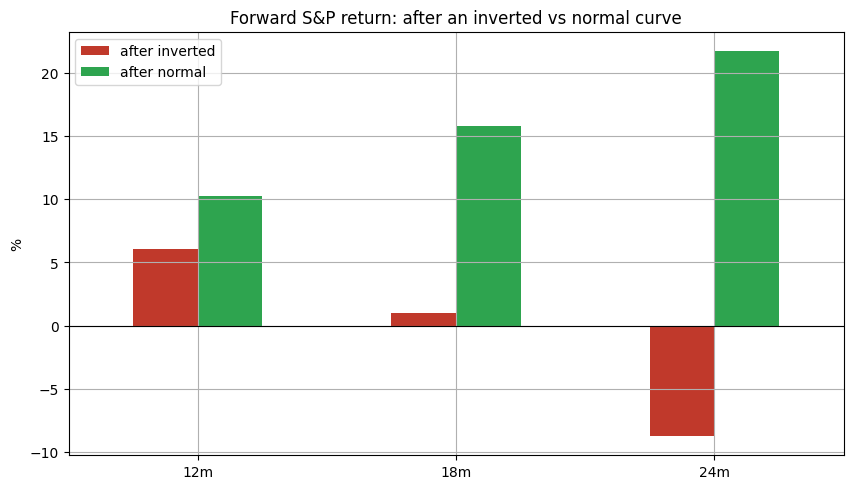

In [2]:
rows={}
for h in (12,18,24):
    c=st.conditional_forward(slope,d['eq'],h); rows[f'{h}m']={'after inverted':c['inverted_fwd'],'after normal':c['normal_fwd']}
tbl=pd.DataFrame(rows).T
ax=(tbl*100).plot.bar(rot=0,color=['#c0392b','#2ea44f'],title='Forward S&P return: after an inverted vs normal curve')
ax.set_ylabel('%'); ax.axhline(0,color='k',lw=.8); plt.show()

## 4 · The teardown — the signal strengthens with horizon

An inversion barely dents the next year; the 18–24-month window — when the recession bites — is flat-to-negative.

In [3]:
for h in (12,18,24):
    c=st.conditional_forward(slope,d['eq'],h)
    print(f"{h}m: inverted {c['inverted_fwd']:+.1%} vs normal {c['normal_fwd']:+.1%} (gap {c['gap']:+.1%})")
print(f"curve inverted {st.conditional_forward(slope,d['eq'],18)['inverted_share']:.0%} of months")

12m: inverted +6.1% vs normal +10.3% (gap -4.2%)
18m: inverted +1.0% vs normal +15.8% (gap -14.8%)
24m: inverted -8.7% vs normal +21.7% (gap -30.4%)
curve inverted 5% of months


**Read it plainly.** The warning is real and large at 18–24 months — but rare and slow. Markets famously melt up *into* the inversion (1998, 2006, 2019, 2023) before the eventual fall.

## 5 · The verdict

**Signal: Real** — +1%/−9% vs +16%/+22% at 18–24m. **Tradability: Fragile** — rare, slow, variable-lag, near-term unreliable. **Forecasts downturns?: Confirmed.**

## 6 · Could you actually trade it?

Not as a switch. Selling the day the curve inverts has you out for a year of gains, on average, before the drop. Its honest use is to *shade your risk* — trim, hold dry powder — when the odds of a downturn rise, not to time the top.

## 7 · Going further 🚪

The macro cousin of [56 Tide-Table](../../56-tide-table/) (CAPE): a real long-horizon predictor that's a poor short-horizon timer.